In [1]:
import pandas as pd

In [5]:
df = pd.read_csv("C:/Users/14/Desktop/淘宝交易数据/data/UserBehavior_2025.csv")

In [6]:
df.head()

,用户ID,商品ID,品牌,品牌ID,商品名称,商品类别,商品类目ID,行为类型,时间戳,售价
0,467451,9215998,GAP,392,GAP卫衣 连帽款 蓝色 XL码,服装鞋帽,6347472,buy,1735741995,171.39
1,423371,6077289,小米,643256,小米14 Ultra 1TB 白色,电子产品,1788515,pv,1735671449,4149.68
2,164065,9178917,欧莱雅,138983,欧莱雅面霜 50ml,美妆护肤,7040903,buy,1735730385,1626.43
3,356777,3375642,蒙牛,195634,蒙牛早餐奶 250ml*16盒,食品饮料,7142910,pv,1735736984,90.23
4,661620,3822663,小米,643256,小米Pad 6 Pro 8GB/256GB,电子产品,1788515,pv,1735691382,4586.06


In [7]:
df.shape

(69555, 10)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69555 entries, 0 to 69554
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   用户ID    69555 non-null  int64  
 1   商品ID    69555 non-null  int64  
 2   品牌      69555 non-null  object 
 3   品牌ID    69555 non-null  int64  
 4   商品名称    69555 non-null  object 
 5   商品类别    69555 non-null  object 
 6   商品类目ID  69555 non-null  int64  
 7   行为类型    69555 non-null  object 
 8   时间戳     69555 non-null  int64  
 9   售价      69555 non-null  float64
dtypes: float64(1), int64(5), object(4)
memory usage: 5.3+ MB


In [10]:
df['行为类型'].value_counts()

行为类型
buy    48370
pv     14129
fav     7056
Name: count, dtype: int64

In [31]:
df['时间戳'].head()

0    1735741995
1    1735671449
2    1735730385
3    1735736984
4    1735691382
Name: 时间戳, dtype: int64

In [34]:
df['时间戳'] = pd.to_datetime(df['时间戳'], unit='s')
df['date'] = df['时间戳'].dt.date
df['hour'] = df['时间戳'].dt.hour
df['dayofweek'] = df['时间戳'].dt.dayofweek
df['month'] = df['时间戳'].dt.month

行为类型
buy    48370
pv     14129
fav     7056
Name: count, dtype: int64


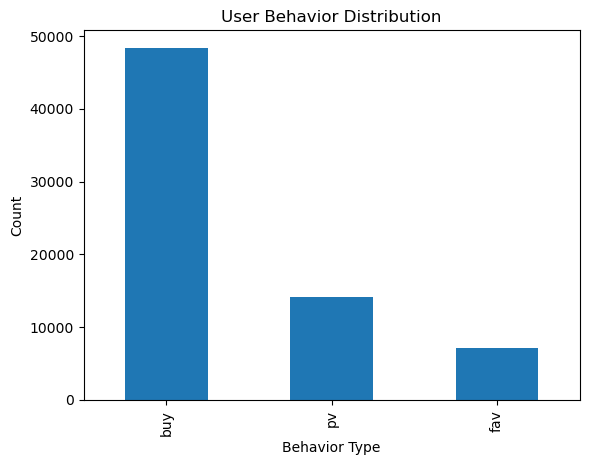

In [35]:
behavior_counts = df['行为类型'].value_counts()
print(behavior_counts)

import matplotlib.pyplot as plt

behavior_counts.plot(kind='bar')
plt.title("User Behavior Distribution")
plt.xlabel("Behavior Type")
plt.ylabel("Count")
plt.show()

行为类型
buy    47138
fav     7023
pv     14023
Name: 用户ID, dtype: int64


C:\Users\14\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 34892 (\N{CJK UNIFIED IDEOGRAPH-884C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\14\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20026 (\N{CJK UNIFIED IDEOGRAPH-4E3A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\14\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 31867 (\N{CJK UNIFIED IDEOGRAPH-7C7B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\14\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 22411 (\N{CJK UNIFIED IDEOGRAPH-578B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


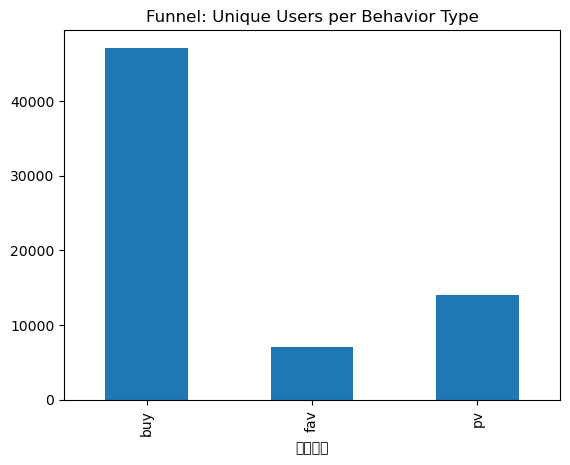

In [36]:
funnel = df.groupby('行为类型')['用户ID'].nunique()

print(funnel)

funnel.plot(kind='bar')
plt.title("Funnel: Unique Users per Behavior Type")
plt.show()

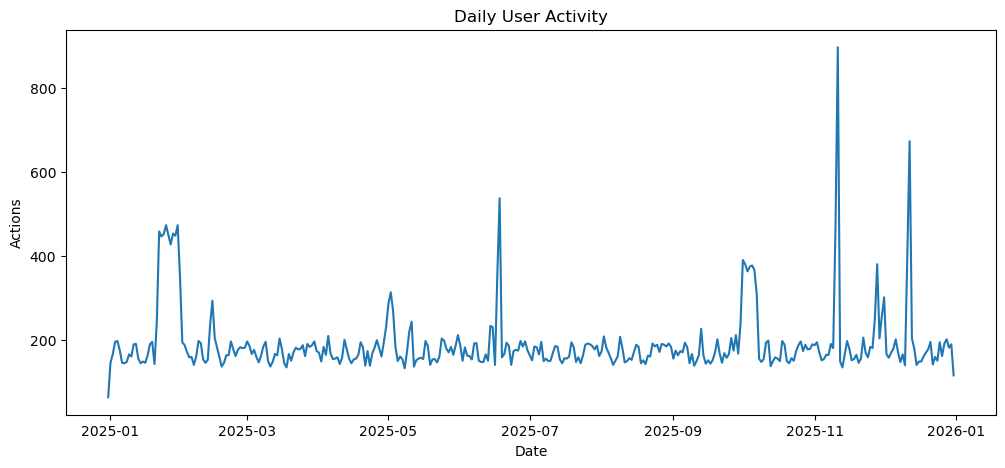

In [37]:
daily_active = df.groupby('date')['用户ID'].count()

plt.figure(figsize=(12,5))
daily_active.plot()
plt.title("Daily User Activity")
plt.xlabel("Date")
plt.ylabel("Actions")
plt.show()

In [45]:
user_path = df.sort_values(['用户ID', '时间戳'])

sample_user = user_path[user_path['用户ID'] == user_path['用户ID'].iloc[0]]
print(sample_user[['时间戳', '行为类型', '品牌ID']])

                      时间戳 行为类型  品牌ID
45409 2025-09-01 20:03:56  buy   392
